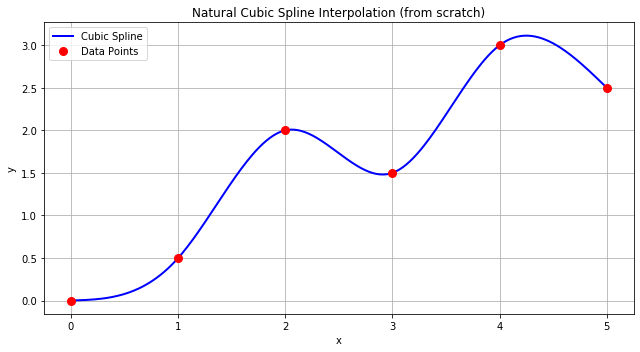

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Define Known Data Points

# x and y are the known data points the spline must pass through
x = np.array([0.0, 1.0, 2.0, 3.0, 4.0, 5.0])
y = np.array([0.0, 0.5, 2.0, 1.5, 3.0, 2.5])

n = len(x)  # number of data points

# Step 2: Calculate Step Sizes

# h[i] = x[i+1] - x[i]: distance between consecutive x-coordinates
h = np.zeros(n - 1)
for i in range(n - 1):
    h[i] = x[i + 1] - x[i]

# Step 3: Set Up and Solve the Tridiagonal System

# We solve for the second derivatives M[i] at each data point.
# Natural spline boundary conditions: M[0] = 0 and M[n-1] = 0.
# The interior points (1 to n-2) satisfy a tridiagonal system.

num_interior = n - 2  # number of interior equations

# Initialize tridiagonal matrix components:
# A = sub-diagonal, B = main diagonal, C = super-diagonal, D = right-hand side
A = np.zeros(num_interior)  # sub-diagonal coefficients
B = np.zeros(num_interior)  # main diagonal coefficients
C = np.zeros(num_interior)  # super-diagonal coefficients
D = np.zeros(num_interior)  # right-hand side values

for i in range(num_interior):
    k = i + 1  # map interior index back to global index

    # Sub-diagonal: coefficient of M[k-1]
    A[i] = h[k - 1]

    # Main diagonal: coefficient of M[k]
    B[i] = 2.0 * (h[k - 1] + h[k])

    # Super-diagonal: coefficient of M[k+1]
    C[i] = h[k]

    # Right-hand side: derived from the finite-difference condition for continuity
    # of the first derivative across knot k
    D[i] = 6.0 * ((y[k + 1] - y[k]) / h[k] - (y[k] - y[k - 1]) / h[k - 1])

# Solve using the Thomas Algorithm

# Forward elimination: modify C and D to eliminate the sub-diagonal
for i in range(1, num_interior):
    w = A[i] / B[i - 1]          # multiplier for elimination
    B[i] = B[i] - w * C[i - 1]   # update diagonal
    D[i] = D[i] - w * D[i - 1]   # update RHS

# Back substitution: solve for the unknowns from bottom to top
interior_M = np.zeros(num_interior)
interior_M[-1] = D[-1] / B[-1]   # last interior second derivative
for i in range(num_interior - 2, -1, -1):
    interior_M[i] = (D[i] - C[i] * interior_M[i + 1]) / B[i]

# Assemble the full array of second derivatives with natural BCs (M_1 = M_n = 0)
M = np.zeros(n)
M[1:-1] = interior_M  # interior values from the tridiagonal solve
# M[0] and M[-1] remain 0 (natural spline boundary conditions)

# Step 4: Evaluate the Spline at New Points
def evaluate_spline(x_data, y_data, h, M, x_eval):
    """
    Evaluate the natural cubic spline at a single point x_eval.

    Parameters
    ----------
    x_data : array of knot x-coordinates
    y_data : array of knot y-values
    h      : array of step sizes between consecutive knots
    M      : array of second derivatives at each knot
    x_eval : the x-value at which to evaluate the spline

    Returns
    -------
    The interpolated y-value at x_eval.
    """
    n = len(x_data)

    # Find the correct interval [x_data[i], x_data[i+1]] that contains x_eval
    # Clamp to the first or last interval if x_eval is outside the data range
    idx = n - 2  # default to last interval
    for i in range(n - 1):
        if x_eval <= x_data[i + 1]:
            idx = i
            break

    # Distances from x_eval to the interval endpoints
    dx_right = x_data[idx + 1] - x_eval  # distance to right knot
    dx_left  = x_eval - x_data[idx]      # distance to left knot
    hi       = h[idx]                    # width of this interval

    # Cubic spline formula built from the second derivatives:
    #   S(x) = (M[i]*(x_{i+1}-x)^3 + M[i+1]*(x-x_i)^3) / (6*h_i)
    #        + (y[i]/h_i - M[i]*h_i/6)*(x_{i+1}-x)
    #        + (y[i+1]/h_i - M[i+1]*h_i/6)*(x-x_i)
    term1 = (M[idx] * dx_right**3) / (6.0 * hi)
    term2 = (M[idx + 1] * dx_left**3) / (6.0 * hi)
    term3 = (y_data[idx] / hi - M[idx] * hi / 6.0) * dx_right
    term4 = (y_data[idx + 1] / hi - M[idx + 1] * hi / 6.0) * dx_left

    return term1 + term2 + term3 + term4

# Generate a dense set of evaluation points for a smooth curve
x_eval = np.linspace(x[0], x[-1], 300)
y_eval = np.array([evaluate_spline(x, y, h, M, xv) for xv in x_eval])

# Plot the Results
plt.figure(figsize=(9, 5))
plt.plot(x_eval, y_eval, 'b-', linewidth=2, label='Cubic Spline')
plt.plot(x, y, 'ro', markersize=8, label='Data Points')
plt.title('Natural Cubic Spline Interpolation (from scratch)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()